# Time series analysis (Part 1)

<span style='color:gray; font-size:10;'> 
This lecture is inspired by an article published in [Towards Data Science](https://towardsdatascience.com/time-series-forecasting-made-simple-part-1-decomposition-baseline-models/) by Nikhil Dasari. </span>


A time series analysis aims to **understand, model and forecast data that is observed over time**. 

Imagine you wanted to predict the temperature during the coming summer. From your experience and intuitition you already know it will be on the warmer side compared to the winter. 


## Decomposition of the time series

We will use real data originated from the SMEAR Estonia station. For convenience I have already compiled a dataset of daily minimum temperatures for the years 2014 to 2023. Why minimum temperatures? Well, if we would use as example daily mean temperatures then we could miss out easily some features of the seasonal pattern we expect to see. The mean and even the more robust median could be very similar depending on the daily span of the temperature. A 15˚C mean/median can occur with a span of 10˚C - 20˚C or with 5˚C - 25˚C and these temperatures may occur in Estonia in Spring, Summer or Autumn.  

### What do we expect from the multiyear timeseries?

1. The temperatures will "wobble" up and down over the year - seasonality
2. We expect to have "noise" in the data because temperature depend on many factors including synoptic scale deep and high pressure systems, wind, sunlight, clouds, local effects, etc. 
3. We also expect a trends, one due to season and another one due to climate warming over longer periods like a decade.

**That is why we want to decompose the time series into it's building blocks!**


        date  min_temperature
0 2014-08-28         9.500000
1 2014-08-29         7.333333
2 2014-08-30         4.000000
3 2014-08-31         4.366667
4 2014-09-01         5.933333
date               datetime64[ns]
min_temperature           float64
dtype: object


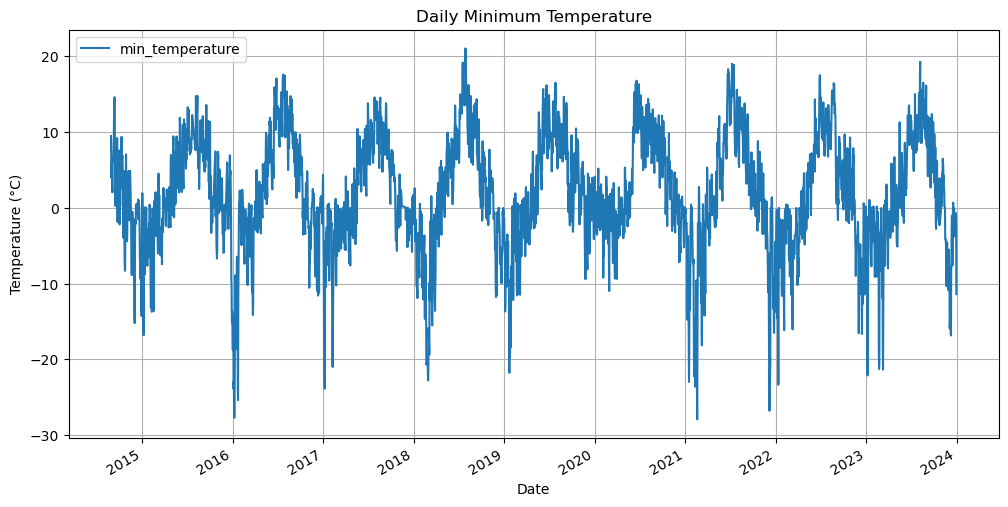

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load the data
df = pd.read_csv('data/SMEAR_2m_daily_min_temperature.csv', parse_dates=['date'])
print(df.head()) # See hat we have
print(df.dtypes) # Check data types

# Set the 'date' as the index
df.set_index('date', inplace=True)

df.plot(y='min_temperature', title='Daily Minimum Temperature', figsize=(12, 6))
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid()
plt.show()

In [6]:
# Set a regular daily frequency and fill missing values using forward fill
df = df.asfreq('D')
df['min_temperature'] = df['min_temperature'].ffill()


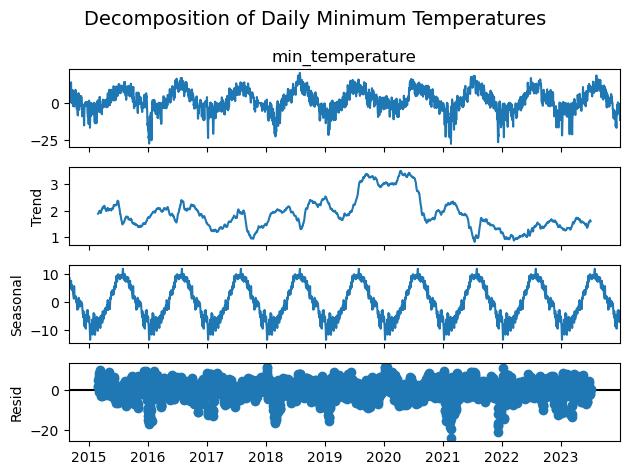

In [7]:
# Decompose the daily series (365-day seasonality for yearly patterns)
decomposition = seasonal_decompose(df['min_temperature'], model='additive', period=365)

# Plot the decomposed components
decomposition.plot()
plt.suptitle('Decomposition of Daily Minimum Temperatures', fontsize=14)
plt.tight_layout()
plt.show()

## What does the decomposition tell us?

The top panel is the original data (same as first picture), then we have the overall trend, the seasonal trend and the residuals. 

### Trend

We can see that there is a more or less stable trend around 1.5°C to 2°C with some rising values in the years 2028 to 2020 with the highest annual deviation of 3°C in 2020. During the last two years (2022 and 2023) of the dataset the trend is a bit lower but again rising. 

### Seasonal

The seasonal part shows the clear change of the minimum temperature over the season as we expect it is ranging from approximately 10°C in summer to -10°C in winter.

### Residuals

The residuals represent those parts of the time series that are not explained by either the trend or the seasonality. We see that some unexplained noise in thedata is linked to short term colder or warmer periods in the data. For instance, the year 2020 had a very warm winter 2019/2020 but then in 2021, the winter got very cold in February. 

### A note on the choice of the additive model

I choose the additive model because there was no extreme change in the seasonal pattern (Figure 1) visible that would hint to some distortion effect e.g., smaller seasonal variation in the beginning and larger in the end of the time series, that would suggest a multiplicative model. N.b. both types are so called "naive" decompostions using a moving average approach (therefore the gaps in the trend and residuals of half a year) which may miss rapid changes or do not perform well on very noisy data.

However, such "naive" approaches are very often a very good "first guess" and if they work out there is no need to overcomplicate the process.

The additive model assumes:

$Y = T + S + R$ 

where $Y$ is the observed value, $T$ is the trend, $S$ the seasonal component and $R$ the residuals (noise).

## Can we make some temperature forecast based on this knowledge?

We can see the strong seasonal pattern which let us assume that a **Seasonal Naive Model** can do the job. We can simply assume that the temperature at a certain day in one year will be likely the same as in a season (year) before.

**Such a model is called a baseline model!**
 

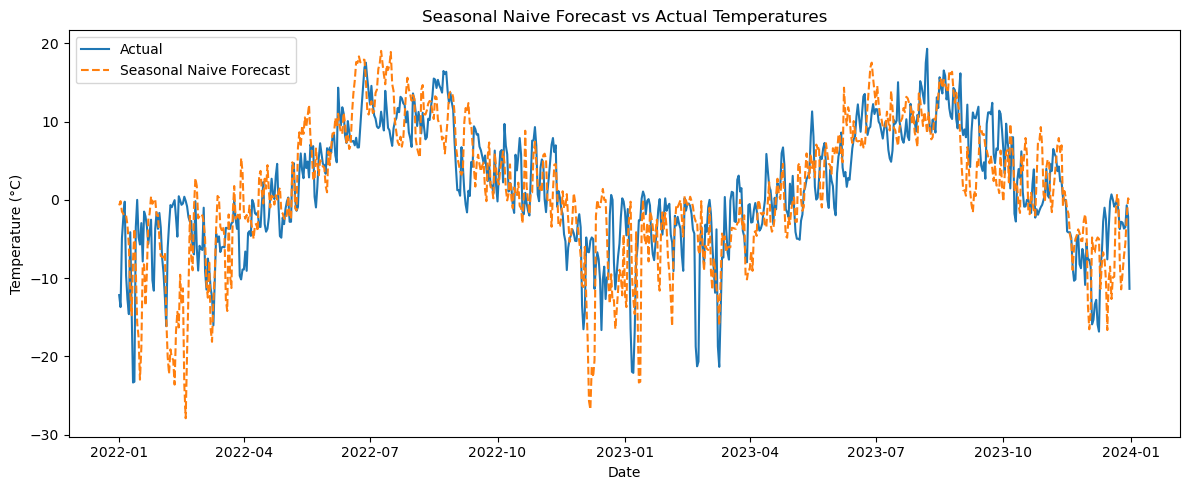

SMAPE (Seasonal Naive Forecast): 22.75%


In [8]:
# Step 1: Create the Seasonal Naive Forecast
seasonal_period = 365  # Assuming yearly seasonality for daily data
# Create the Seasonal Naive forecast by shifting the temperature values by 365 days
df['Seasonal_Naive'] = df['min_temperature'].shift(seasonal_period)

# Step 2: Plot the actual vs forecasted values
# Plot the last 2 years (730 days) of data to compare
plt.figure(figsize=(12, 5))
plt.plot(df['min_temperature'][-730:], label='Actual')
plt.plot(df['Seasonal_Naive'][-730:], label='Seasonal Naive Forecast', linestyle='--')
plt.title('Seasonal Naive Forecast vs Actual Temperatures')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

# Step 3: Evaluate using MAPE (Mean Absolute Percentage Error)
# Use the last 365 days for testing
test = df[['min_temperature', 'Seasonal_Naive']].iloc[-365:].copy()
test.dropna(inplace=True)

# SMAPE Calculation
smape = np.mean(np.abs(test['min_temperature'] - test['Seasonal_Naive']) / (np.abs(test['min_temperature']) + np.abs(test['Seasonal_Naive']))/2) * 100
print(f"SMAPE (Seasonal Naive Forecast): {smape:.2f}%")

## How well did we do and some other caveats

We used to calculate the **symmetric mean absolute percentage error (SMAPE)** which is measure for prediction accuracy in statistical models. 

$\textrm{SMAPE} = \frac{1}{n} \sum_{t=1}^{n} \frac{|F_t - A_t|}{(|A_t|+|F_t|)/2} 100\%$

In our case we can not use the simpler **mean absolute percentage error (MAPE)** because we do have some zero degree values  which lead to division by zero errors or in case of very small values to wrong percentage estimates. 

We used the year 2022 to predict according our naive approach the year 2023 and we can see that our predictions are on average 22.75% off from the actual value. 